**Dataset Reuters**

Dataset com 11228 documentos de notícias. Este é um conjunto de dados para classificação de texto multiclasse, especialmente para categorização de notícias. Há 46 tópicos mais frequentes (classes)

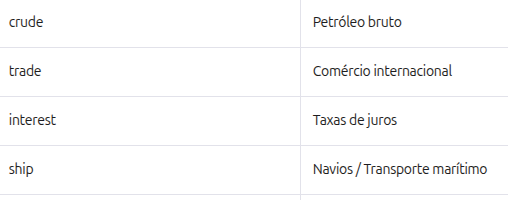

In [1]:
from keras import layers
from keras import models
from keras import preprocessing
from keras import datasets
from keras import utils

In [2]:
max_words = 5000

maxlen = 250

num_classes = 46

(X_train, Y_train), (X_val, Y_val) = datasets.reuters.load_data(num_words = max_words)

X_train = preprocessing.sequence.pad_sequences(X_train, maxlen)
X_val = preprocessing.sequence.pad_sequences(X_val, maxlen = maxlen)

Y_train = utils.to_categorical(Y_train, num_classes)
Y_val = utils.to_categorical(Y_val, num_classes)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


c:\AI\postgrad-ai\.venv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [3]:
model = models.Sequential()

embedding_dims = 50

inputs = layers.Input(shape=(maxlen,))

model.add(inputs)

model.add(layers.Embedding(max_words, embedding_dims))

rnn_units = 64

#model.add(layers.SimpleRNN(rnn_units, activation = 'relu', return_sequences=False))
model.add(layers.LSTM(rnn_units))
#model.add(layers.GRU(rnn_units))

model.add(layers.Dropout(0.3))

model.add(layers.Dense(num_classes, activation ='softmax'))

In [4]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics=['accuracy'])

model.summary()

model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs = 10, batch_size = 32)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 50)        │       250,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,430 (1.08 MB)

 Trainable params: 282,430 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.3990 - loss: 2.3060 - val_accuracy: 0.4096 - val_loss: 2.0626
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.5020 - loss: 1.8620 - val_accuracy: 0.5565 - val_loss: 1.7284
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.5641 - loss: 1.7287 - val_accuracy: 0.5481 - val_loss: 1.7509
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5924 - loss: 1.5800 - val_accuracy: 0.6011 - val_loss: 1.5748
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6271 - loss: 1.4705 - val_accuracy: 0.6269 - val_loss: 1.5007
Epoch 6/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6319 - loss: 1.4581 - val_accuracy: 0.6175 - val_loss: 1.5260
Epoch 7/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6134 - loss: 1.4888 - val_accuracy: 0.6069 - val_loss: 1.5343
Epoch 8/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6641 - loss: 1.3082 - val_accu